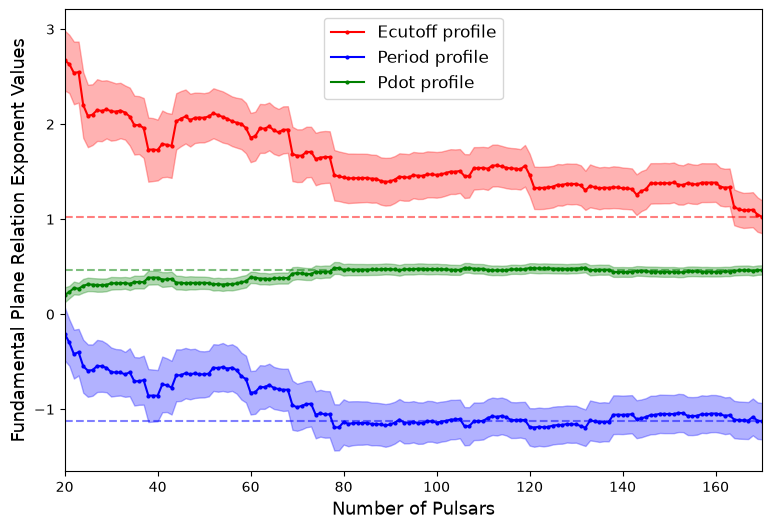

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Verileri oku ve sırala
df = pd.read_csv('TScut_verisi.csv')
df = df.sort_values(by='TSband', ascending=False)

# Loglar hata vermesin diye 0dan büyük şartı
df = df[
    (df['LUMG'] > 0) & 
    (df['ECut_HYB'] > 0) & 
    (df['P'] > 0) & 
    (df['PdotCor'] > 0)
].copy()

# Log versiyonlarını kaydetme
df['L_log'] = np.log10(df['LUMG'])
df['P_log'] = np.log10(df['P'])
df['Pdot_log'] = np.log10(df['PdotCor'])
df['Ecut_log'] = np.log10(df['ECut_HYB'])

# Boş liste oluşturuyorum ki sonradan içine koyayım tek tek
pulsars = []
beta_val, beta_err = [], []     # Ecut katsayısı için
gamma_val, gamma_err = [], []   # Period katsayısı için
delta_val, delta_err = [], []   # Pdot katsayısı için

min_pulsar = 20
total_pulsar = len(df)

# Döngü halinde pulsar sayısını arttırarak fit ediyorum
for i in range(min_pulsar, total_pulsar+1):
    df_subset = df.iloc[:i]
    X = df_subset[['Ecut_log', 'P_log', 'Pdot_log']]
    X = sm.add_constant(X)
    Y = df_subset['L_log']
    model = sm.OLS(Y, X).fit()

    pulsars.append(i)

    beta_val.append(model.params['Ecut_log'])
    beta_err.append(model.bse['Ecut_log']) 

    gamma_val.append(model.params['P_log'])
    gamma_err.append(model.bse['P_log'])

    delta_val.append(model.params['Pdot_log'])
    delta_err.append(model.bse['Pdot_log'])

beta_val, beta_err = np.array(beta_val), np.array(beta_err)
gamma_val, gamma_err = np.array(gamma_val), np.array(gamma_err)
delta_val, delta_err = np.array(delta_val), np.array(delta_err)

# Grafiği çizdirme
plt.figure(figsize=(9, 6))

# Ecut - Kırmızı çizgi
plt.plot(pulsars, beta_val, color='red', label='Ecutoff profile', linewidth=1.5, marker='.', markersize=4)
plt.fill_between(pulsars, beta_val - beta_err, beta_val + beta_err, color='red', alpha=0.3)

# Period - Mavi çizgi
plt.plot(pulsars, gamma_val, color='blue', label='Period profile', linewidth=1.5, marker='.', markersize=4)
plt.fill_between(pulsars, gamma_val - gamma_err, gamma_val + gamma_err, color='blue', alpha=0.3)

# Pdot - Yeşil çizgi
plt.plot(pulsars, delta_val, color='green', label='Pdot profile', linewidth=1.5, marker='.', markersize=4)
plt.fill_between(pulsars, delta_val - delta_err, delta_val + delta_err, color='green', alpha=0.3)

plt.axhline(y=beta_val[-1], color='red', linestyle='--', alpha=0.5)
plt.axhline(y=gamma_val[-1], color='blue', linestyle='--', alpha=0.5)
plt.axhline(y=delta_val[-1], color='green', linestyle='--', alpha=0.5)

# Eksenler
plt.xlim(min_pulsar, total_pulsar)
plt.xlabel('Number of Pulsars', fontsize=13)
plt.ylabel('Fundamental Plane Relation Exponent Values', fontsize=13)
plt.legend(loc='upper center', fontsize=12)

plt.show()




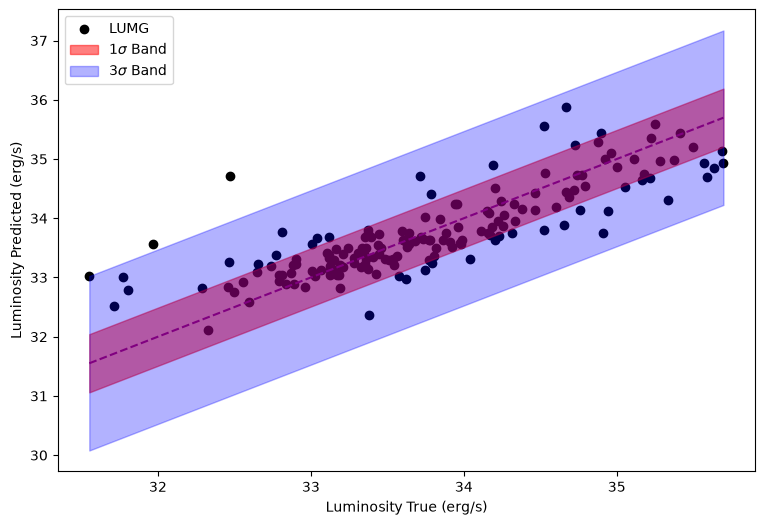

In [8]:

# Hata grafiği
X_eksen = df_subset['L_log'] #Yukarıdaki koddan
Y_eksen = model.fittedvalues #Modelden çıkan tahmini sonuçlar

#Sigma hesaplama
d = X_eksen - Y_eksen
sigma = np.std(d)

#Grafik çizimi
plt.figure(figsize= (9,6))
plt.scatter(X_eksen , Y_eksen , color= 'black',label= 'LUMG')
x_line= np.linspace(min(X_eksen),max(X_eksen))
y_line= x_line
plt.plot(x_line, y_line, color= 'purple', linestyle= '--')
plt.fill_between(x_line, y_line - sigma, y_line + sigma, alpha=0.5 , color='red', label= '1$\sigma$ Band')
plt.fill_between(x_line, y_line - (3*sigma), y_line + (3*sigma), alpha=0.3, color='blue',label= '3$\sigma$ Band')
plt.xlabel('Luminosity True (erg/s)')
plt.ylabel('Luminosity Predicted (erg/s)')
plt.legend(loc='upper left')
plt.show()


